## Model 1: MARCEL

The target parameter is wRC+.

Both the deterministic and Bayesian MARCEL models will be developed. The deterministic model will be an attempt to directly replicate Tom Tango's MARCEL model. The Bayesian MARCEL will follow PyMC Labs' implementation of Bayesian MARCEL for projecting hard hit rate. 

In [69]:
# Loading packages
import numpy as np
import pandas as pd
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm
from pathlib import Path
from scipy import stats

# Loading data
data_path = Path.cwd()
while not (data_path / "data" / "fangraphs" / "fg_hitters.csv").exists() and data_path != data_path.parent:
    data_path = data_path.parent

data_path = data_path / "data" / "fangraphs" / "fg_hitters.csv"

print(f"Loading data from {data_path}")
data = pd.read_csv(data_path)

Loading data from c:\Users\19175\Documents\personal\classes\LSE\ST451-Bayesian_ML\project\data\fangraphs\fg_hitters.csv


In [ ]:
# Creating filtered versions of the full data

df1 = data[(data["primary_pos"] != "P") | (data["Name"] == "Shohei Ohtani")][["IDfg", "Name", "Season", "primary_pos", "Team",
             "Age", "G", "PA", "OPS", "wOBA", "wRC+",
            "BsR", "Spd", "WAR", "K%", "BB%", "ISO", 
            "Hard%", "EV", "LA", "Barrel%", "maxEV", 
            "LD%", "Z-Contact%", "Contact%", "O-Contact%",
            "O-Swing%", "Z-Swing%", "Zone%", "xwOBA",
            "BABIP"]]

train = df1[df1["Season"] <= 2023]

test = df1[df1["Season"] == 2024]

### Deterministic MARCEL

1. 5/4/3 Weighting of past season wRC+
2. Aging curve: if over 29: $(29 - A)*0.006$; if under 29: $(29 - A)*0.003$ (multiplicative)
3. Regression to the mean: since wRC+ is already normalized to 100, I will add 1200 PAs of 100 wRC+ to every projection. 

In [58]:
marcel_det = train[train["Season"] >= 2021][["IDfg", "Name", "Season", "Age", "primary_pos", "wRC+", "PA"]]
marcel_det["weight"] = (marcel_det["Season"] - 2021 + 3)*marcel_det["PA"] / 1000
marcel_det["weighted_wrc"] = marcel_det["weight"]*marcel_det["wRC+"]

marcel_det_preds = pd.DataFrame(marcel_det.groupby(["IDfg"], group_keys=False).apply(lambda g: (((g.weighted_wrc).sum() + 120)/((g.weight).sum() + 1.2))*(1 - 0.006*((g.Age.max() + 1) - 29)) if g.Age.max() + 1 >= 29
                                        else (((g.weighted_wrc).sum() + 120)/((g.weight).sum() + 1.2))*(1 + 0.003*(29 - (g.Age.max() + 1)))).reset_index())
marcel_det_preds.columns = ["IDfg", "MARCEL_DET_wRC+"]

# Sum of raw weights across all seasons for each player (before regression-to-mean adjustment)
weight_sums = marcel_det.groupby("IDfg")["weight"].sum()
marcel_det_preds["weight_sum"] = marcel_det_preds["IDfg"].map(weight_sums)                                                                        

C:\Users\19175\AppData\Local\Temp\ipykernel_40744\641501721.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  marcel_det_preds = pd.DataFrame(marcel_det.groupby(["IDfg"], group_keys=False).apply(lambda g: (((g.weighted_wrc).sum() + 120)/((g.weight).sum() + 1.2))*(1 - 0.006*((g.Age.max() + 1) - 29)) if g.Age.max() + 1 >= 29


#### Model

In [65]:
mdet_comp = test.join(marcel_det_preds.set_index("IDfg"),
                       on = "IDfg")[["IDfg", "Name", 
                                     "Age", "primary_pos",
                                     "G", "PA",
                                     "wRC+", "MARCEL_DET_wRC+", "weight_sum",
                                     "xwOBA", "BABIP", "K%", "BB%"]]
mdet_comp["MARCEL_DET_wRC+"] = mdet_comp["MARCEL_DET_wRC+"].fillna(100)
mdet_comp["MARCEL_DET_ERROR"] = mdet_comp["MARCEL_DET_wRC+"] - mdet_comp["wRC+"]

#### Evaluation

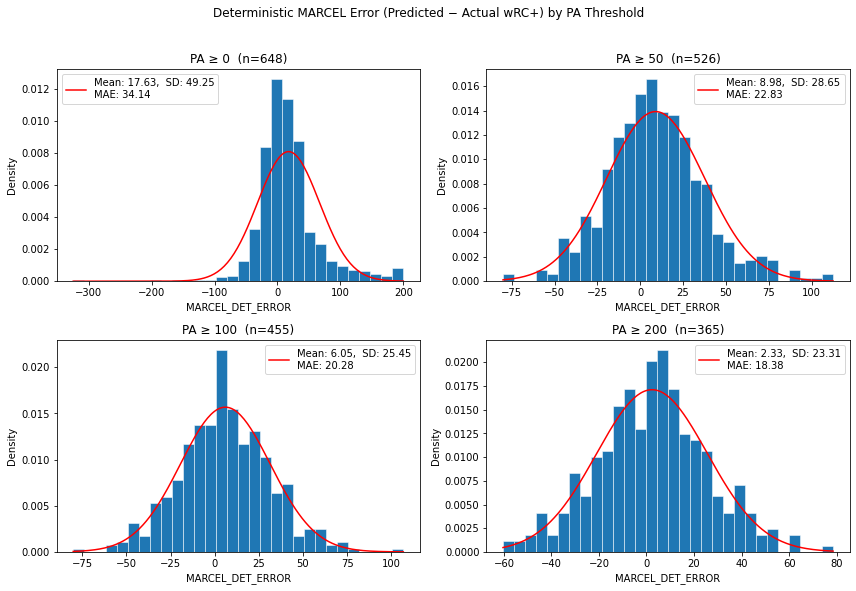

In [80]:
# Histogram of deterministic MARCEL errors by PA threshold
col = "MARCEL_DET_ERROR"
pa_thresholds = [0, 50, 100, 200]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, min_pa in zip(axes.flat, pa_thresholds):
    filtered = mdet_comp[mdet_comp["PA"] >= min_pa][col].dropna()
    mae = filtered.abs().mean()

    ax.hist(filtered, bins=30, edgecolor="white", linewidth=0.5, density=True)

    x = np.linspace(filtered.min(), filtered.max(), 200)
    ax.plot(x, stats.norm.pdf(x, filtered.mean(), filtered.std()), color="red", linewidth=1.5,
            label=f"Mean: {filtered.mean():.2f},  SD: {filtered.std():.2f}\nMAE: {mae:.2f}")

    ax.set_title(f"PA ≥ {min_pa}  (n={len(filtered)})")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

fig.suptitle("Deterministic MARCEL Error (Predicted − Actual wRC+) by PA Threshold", y=1.02)
plt.tight_layout()
plt.show()


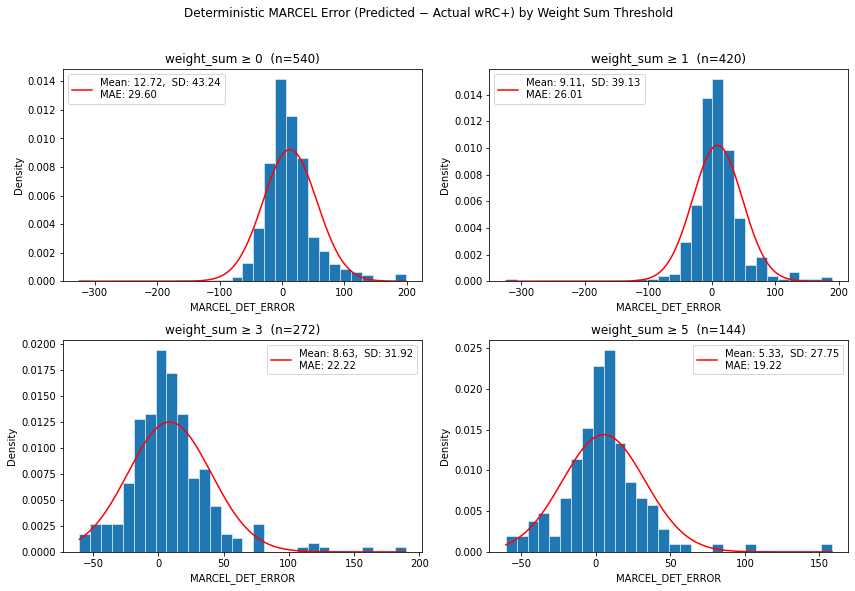

In [79]:
# Histogram of deterministic MARCEL errors by weight_sum threshold
col = "MARCEL_DET_ERROR"
weight_thresholds = [0, 1, 3, 5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, min_w in zip(axes.flat, weight_thresholds):
    filtered = mdet_comp[mdet_comp["weight_sum"] >= min_w][col].dropna()
    mae = filtered.abs().mean()

    ax.hist(filtered, bins=30, edgecolor="white", linewidth=0.5, density=True)

    x = np.linspace(filtered.min(), filtered.max(), 200)
    ax.plot(x, stats.norm.pdf(x, filtered.mean(), filtered.std()), color="red", linewidth=1.5,
            label=f"Mean: {filtered.mean():.2f},  SD: {filtered.std():.2f}\nMAE: {mae:.2f}")

    ax.set_title(f"weight_sum ≥ {min_w}  (n={len(filtered)})")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

fig.suptitle("Deterministic MARCEL Error (Predicted − Actual wRC+) by Weight Sum Threshold", y=1.02)
plt.tight_layout()
plt.show()



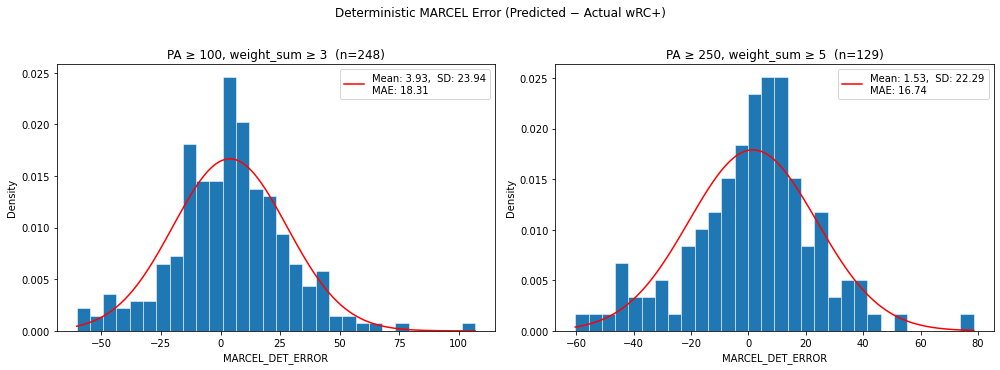

In [84]:
# Performance for medium and high information players

col = "MARCEL_DET_ERROR"
thresholds = [
    {"pa": 100,  "w": 3},
    {"pa": 250, "w": 5}
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, t in zip(axes, thresholds):
    filtered = mdet_comp[(mdet_comp["PA"] >= t["pa"]) & (mdet_comp["weight_sum"] >= t["w"])][col].dropna()
    mae = filtered.abs().mean()

    ax.hist(filtered, bins=30, edgecolor="white", linewidth=0.5, density=True)

    x = np.linspace(filtered.min(), filtered.max(), 200)
    ax.plot(x, stats.norm.pdf(x, filtered.mean(), filtered.std()), color="red", linewidth=1.5,
            label=f"Mean: {filtered.mean():.2f},  SD: {filtered.std():.2f}\nMAE: {mae:.2f}")

    ax.set_title(f"PA ≥ {t['pa']}, weight_sum ≥ {t['w']}  (n={len(filtered)})")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

fig.suptitle("Deterministic MARCEL Error (Predicted − Actual wRC+)", y=1.02)
plt.tight_layout()
plt.show()


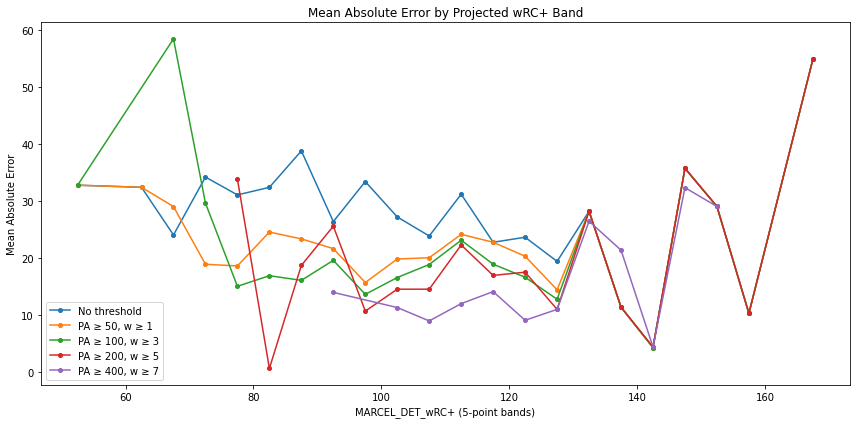

In [85]:
col = "MARCEL_DET_ERROR"
thresholds = [
    {"label": "No threshold",         "pa": 0,   "w": 0},
    {"label": "PA ≥ 50, w ≥ 1",  "pa": 50,  "w": 1},
    {"label": "PA ≥ 100, w ≥ 3", "pa": 100, "w": 3},
    {"label": "PA ≥ 200, w ≥ 5", "pa": 200, "w": 5},
    {"label": "PA ≥ 400, w ≥ 7", "pa": 400, "w": 7},
]

# Build bins in 5-point increments across the full range of projected wRC+
bin_min = int(np.floor(mdet_comp["MARCEL_DET_wRC+"].min() / 5) * 5)
bin_max = int(np.ceil(mdet_comp["MARCEL_DET_wRC+"].max() / 5) * 5)
bins = np.arange(bin_min, bin_max + 5, 5)
bin_centers = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(figsize=(12, 6))

for t in thresholds:
    filtered = mdet_comp[(mdet_comp["PA"] >= t["pa"]) & (mdet_comp["weight_sum"] >= t["w"])].copy()
    filtered["band"] = pd.cut(filtered["MARCEL_DET_wRC+"], bins=bins, labels=bin_centers)
    mae_by_band = filtered.groupby("band", observed=True)[col].apply(lambda x: x.abs().mean())
    ax.plot(mae_by_band.index.astype(float), mae_by_band.values, marker="o", markersize=4, label=t["label"])

ax.set_title("Mean Absolute Error by Projected wRC+ Band")
ax.set_xlabel("MARCEL_DET_wRC+ (5-point bands)")
ax.set_ylabel("Mean Absolute Error")
ax.legend()
plt.tight_layout()
plt.show()


### Bayesian MARCEL

1. Weighting of past season wRC+ according to a Wishart prior
2. Aging curve: piecewise linear specification with a "peak age" and two slope parameters determined by data.
3. Regression to the mean: Normal prior with mean 100 and variance determined by the data. Effect will scale with the amount of data (plate appearances) available for a player. 